# Tutorial 5: Line Profiles

`pygid` supports several functions for line profiling of intensity:.

Table 2. Conversion line profile functions

| Function Name          | Output Data Name | Axes Name     | Description                                                                           |
|------------------------|------------------|---------------|---------------------------------------------------------------------------------------|
| `radial_profile_gid()` | `rad_cut_gid`    | `q_gid_pol`   | Makes polar remapping and averages in the given angular range (GID geometry)          |
| `radial_profile()`     | `rad_cut`        | `q_pol`       | Makes polar remapping and averages in the given angular range (transmission geometry) |
| `azim_profile_gid()`   | `azim_cut_gid`   | `ang_gid_pol` | Makes polar remapping and averages in the given radial range (GID geometry)           |
| `azim_profile()`       | `azim_cut`       | `ang_pol`     | Makes polar remapping and averages in the given radial range (transmission geometry)  |
| `horiz_profile_gid()`  | `horiz_cut_gid`  | `q_xy`        | Makes cylindrical remapping and averages in the given $q_z$ range (GID geometry)      |




**Note:** In this tutorial, only GID geometry described.
All other line profiling functions use the same parameters and workflow.


Load datasets from `Zenodo`, and create `params`, `matrix`, and `analysis` instances as described in Tutorials 1–3.

In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_05")
    poni_path = files["poni"]
    mask_path = files["mask"]
    # several files for batch processing
    data_path = files["data"]
except:
    print("Dataset download skipped on Read the Docs.")

In [2]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params  # pygid.ExpParams
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data'  # dataset path
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (13, 2162, 2068)


---
#### **Minimal Code Example**


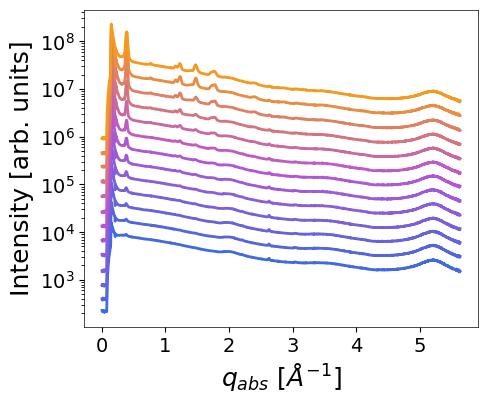

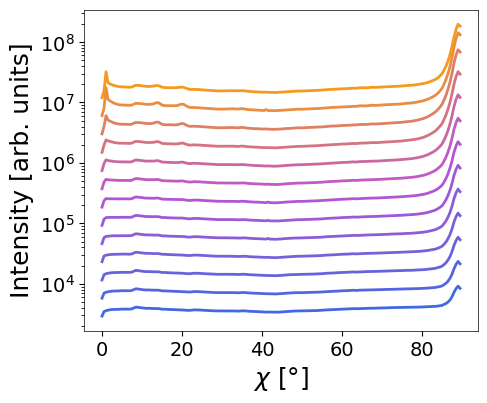

In [8]:
# Radial profile
q, intensity = analysis.radial_profile_gid(
    plot_result=True,
    return_result=True)

# Azimuthal profile
chi, intensity = analysis.azim_profile(
    plot_result=True,
    return_result=True)

---
#### Parameters (for all remapping functions)
Main parameters:
- `frame_num` – index or list of indiced of loaded frames to convert (not the frame number in file). If `None`, all loaded images are converted.
- `return_result` – if `True`, returns converted image and axes arrays. Default is `False`.
- `multiprocessing` – flag to enable multiprocessing. If `None`, uses the default defined in the `Conversion` class.
- `radial_range` - radial range range (tuple, in Å⁻¹)
- `angular_range` - angular range range (tuple, in degrees)
- `q_xy_range` - q_xy range (tuple, in Å⁻¹) for horiz_profile_gid() function
- `q_z_range` - q_z range (tuple, in Å⁻¹) for horiz_profile_gid() function
- `dang` – angular bin size (degrees).
- `dq` – radial  bin size (Å⁻¹).

Saving parameters:
- `save_result` – whether to save the result as an HDF5 file in NXsas format.
- `path_to_save` – output path for the HDF5 result file.
- `h5_group` – name of the NXentry dataset within the HDF5 file.
- `overwrite_file` – if `True`, overwrites existing HDF5 file. Default is `True`.
- `overwrite_group` – if `True`, overwrites existing NXentry group. Default is `True`.
- `exp_metadata` – `ExpMetadata` instance containing experimental information (see [Tutorial 6](tutorial_06_metadata_curation.ipynb)).
- `smpl_metadata` – `SampleMetadata` instance containing sample information (see [Tutorial 6](tutorial_06_metadata_curation.ipynb)).

Plotting parameters:
- `return_fig` - whether to return `fig`, `ax`
- `plot_result` – whether to plot the remapped image.
- `xlim`, `ylim` – tuples defining X and Y axis limits for the plot.
- `save_fig` – whether to save the plotted image to a file.
- `path_to_save_fig` – path to save the plot (e.g. `.png`, `.tiff`).
- `shift`– vertical offset applied to separate multiple plotted curves.


#### Radial profile


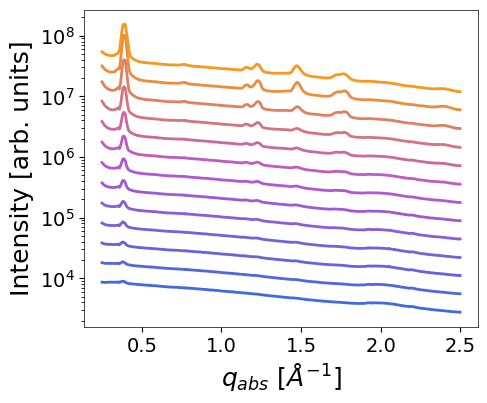

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_radial


q_abs shape (969,)
intensity profiles shape (13, 969)


In [27]:
q, intensity = analysis.radial_profile_gid(
    frame_num=None,                   # Frame(s) to analyse; all if None
    radial_range=(0.25, 2.5),              # Radial q-range in Å⁻¹
    angular_range=(0, 90),            # Angular range in degrees
    dang=0.5,                         # Angular resolution (degrees)
    dq=None,                          # Radial bin width (Å⁻¹)
    return_result=True,               # Return computed q and intensity
    save_result=True,                 # Save result to HDF5
    path_to_save="result.h5",         # Output path
    h5_group="entry_radial",                    # Group name in HDF5
    overwrite_file=True,             # Overwrite HDF5 file
    overwrite_group=False,            # Overwrite NXentry group
    plot_result=True,                 # Plot the radial profile
    shift=1,                        # Vertical offset between curves
)

print(f"q_abs shape {q.shape}")
print(f"intensity profiles shape {intensity.shape}")

Result: 13 radial profiles were saved in "result.h5" in a single entry `entry_radial`

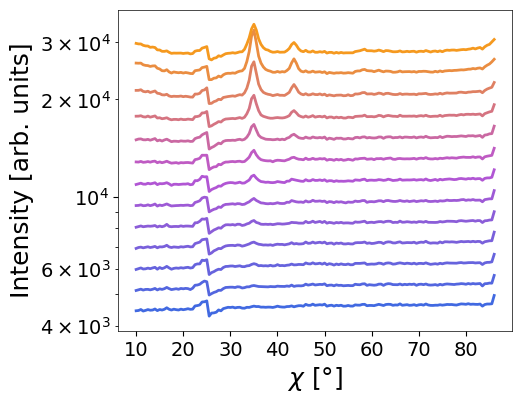

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_azim


chi shape (160,)
intensity profiles shape (13, 160)


In [28]:
chi, intensity = analysis.azim_profile_gid(
    frame_num=None,                   # Frame(s) to analyse; all if None
    radial_range=(1.4, 1.6),          # Radial q-range in Å⁻¹
    angular_range=(10, 90),           # Angular range in degrees
    dang=0.5,                         # Angular resolution (degrees)
    dq=None,                          # Radial bin width (Å⁻¹)
    return_result=True,               # Return computed q and intensity
    save_result=True,                 # Save result to HDF5
    path_to_save="result.h5",         # Output path
    h5_group="entry_azim",            # Group name in HDF5
    overwrite_file=True,              # Overwrite HDF5 file
    overwrite_group=False,            # Overwrite NXentry group
    plot_result=True,                 # Plot the radial profile
    shift=0.2,                        # Vertical offset between curves
)

print(f"chi shape {chi.shape}")
print(f"intensity profiles shape {intensity.shape}")

Result: 13 azimuthal profiles were appended to "result.h5" as separate entry `entry_azim`

NOTE: a new conversion overwrites the result of previous conversion in memory

How to change the plotting defaults (font size, etc.) is described in [Tutorial 12](tutorial_12_visualization.ipynb).